# RPCM Plasma Simulation (3I/ATLAS Analogue)
Simulate plasma self-organization and solar wind elongation for interstellar comet 3I/ATLAS.
Demonstrates clustering and sheaths consistent with the Resonant Plasma Comet Model (RPCM).


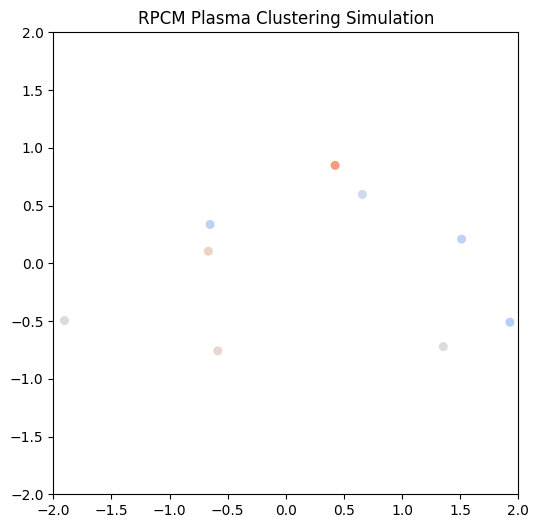

In [2]:
import numpy as np, matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
import matplotlib.animation as animation
from IPython.display import HTML

N, dt, steps, k = 100, 0.01, 200, 1.0
wind_strength, wind_vector = 0.002, np.array([1.0, 0.3])
charge = np.random.uniform(-1, 1, N)
pos, vel = np.random.uniform(-1, 1, (N, 2)), np.zeros((N, 2))

def compute_forces(pos, charge):
    dist = cdist(pos, pos); dist[dist==0] = np.inf
    fmag = k * np.outer(charge, charge) / dist**2
    dx, dy = np.subtract.outer(pos[:,0], pos[:,0]), np.subtract.outer(pos[:,1], pos[:,1])
    fx, fy = fmag * dx / dist, fmag * dy / dist
    return np.nansum(fx, axis=1), np.nansum(fy, axis=1)

positions = [pos.copy()]
for _ in range(steps):
    fx, fy = compute_forces(pos, charge)
    vel += (np.column_stack((fx, fy)) + wind_strength * wind_vector) * dt
    pos += vel * dt; positions.append(pos.copy())

fig, ax = plt.subplots(figsize=(6,6))
scat = ax.scatter(positions[0][:,0], positions[0][:,1], c=charge, cmap='coolwarm', s=30)
ax.set_xlim(-2,2); ax.set_ylim(-2,2)
ax.set_title('RPCM Plasma Clustering Simulation')

def update(i): scat.set_offsets(positions[i]); return scat,
ani = animation.FuncAnimation(fig, update, frames=len(positions), interval=50, blit=True)
HTML(ani.to_jshtml())
